# Loading and Checking All Results After Compilation

In the load_data.py file, the athlete information was loaded from the "Athlete" tab in "Alpine Skiing Data", along with the junior race result information from the "JR Results" tab in "Alpine Skiing Data". The file then read all of the race results data from the JR Historical Results by season (2013-2024) and gender spreadsheets. The program merged/concatenated each individual row from the JR Historical Results so it had the athlete's race results, more information about the race itself, and more information about the athlete and their future world rankings (if applicable). 

This became stored in one super-file called all_results.parquet

That parquet file is loaded here below.

In [29]:
import pandas as pd

df = pd.read_parquet(
    "../data/processed/all_results.parquet"
)
display(df)


,Rank,Bib,ACA,Team,Run1,Run2,Total,Points,Race Code,Season,...,Location,Title,FIS ID,Name,YOB,Gender,GS WR,SL WR,SG WR,DH WR
0,1.0,1.0,80725,GEORG,44.38,45.06,1:29.44,0.0,NAT20.5378,2020,...,"Thunder Bay, ON",OCUP U16 FINALS,108562,"Noakes, Alexis",2004.0,F,1764.0,1441.0,NaN,NaN
1,2.0,3.0,80816,OSLER,44.58,45.58,1:30.16,5.88,NAT20.5378,2020,...,"Thunder Bay, ON",OCUP U16 FINALS,108558,"Hillier, Kyra",2004.0,F,1312.0,1110.0,869.0,NaN
2,3.0,7.0,81243,FORTU,43.98,46.28,1:30.26,6.69,NAT20.5378,2020,...,"Thunder Bay, ON",OCUP U16 FINALS,108576,"Nicolici, Andreea",2004.0,F,340.0,156.0,729.0,NaN
3,4.0,2.0,84825,NATAC,45.2,45.91,1:31.11,13.63,NAT20.5378,2020,...,"Thunder Bay, ON",OCUP U16 FINALS,108556,"Harvey, Marisol",2004.0,F,1369.0,1570.0,712.0,537.0
4,5.0,32.0,78618,TSCBM,45.2,45.93,1:31.13,13.79,NAT20.5378,2020,...,"Thunder Bay, ON",OCUP U16 FINALS,108655,"Wayland, Lauren",2005.0,F,728.0,427.0,493.0,573.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
194201,13.0,29.0,65140,CAN,45.22,48.04,1:33.26,<NA>,AlpeCimbra17.WSL,2017,...,"Folgaria, ITA",Alpe Cimbra,108077,"Gray, Cassidy",2001.0,F,27.0,207.0,107.0,88.0
194202,20.0,43.0,67075,CAN,46.51,47.66,1:34.17,<NA>,AlpeCimbra17.WSL,2017,...,"Folgaria, ITA",Alpe Cimbra,108086,"Lebsack, Avery",2001.0,F,569.0,516.0,395.0,300.0
194203,26.0,71.0,67075,CAN,52.9,55.85,1:48.75,<NA>,AlpeCimbra17.WGS,2017,...,"Folgaria, ITA",Alpe Cimbra,108086,"Lebsack, Avery",2001.0,F,569.0,516.0,395.0,300.0
194204,28.0,41.0,65140,CAN,52.4,57.37,1:49.77,<NA>,AlpeCimbra17.WGS,2017,...,"Folgaria, ITA",Alpe Cimbra,108077,"Gray, Cassidy",2001.0,F,27.0,207.0,107.0,88.0


## Visualizing Results Distribution

Below, you can see 4 plots that show:

* \# of result records by gender
* \# of result records by year of birth (YOB)
* \# of result records by tier (zone, provincial, regional, national, international)
* \# of result records by season

This allows us to view the distribution of the individual results we have in this dataset by numerous variables.

Gender
M    98307
F    95892
Name: count, dtype: Int64


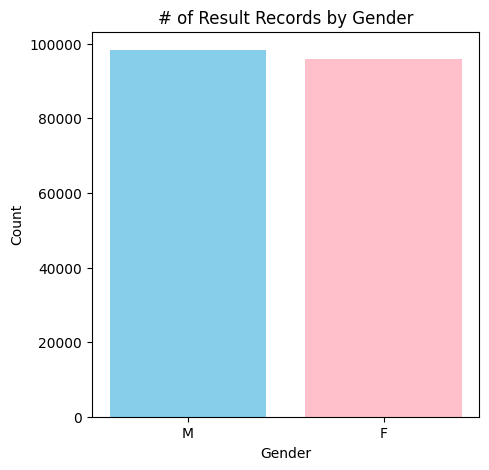

YOB
2001.0    20190
2002.0    18343
2003.0    17816
2004.0    17138
2008.0    14967
2007.0    14646
2000.0    14181
1999.0    13492
2009.0    13415
2005.0    12186
2006.0    11090
1998.0     9301
2010.0     8037
1997.0     4404
2011.0     3964
1996.0      193
2014.0      125
2015.0       82
1995.0       81
2013.0       80
2016.0       76
2012.0       75
2017.0       47
1943.0       40
2018.0       37
1944.0       22
1988.0       21
1959.0       18
1994.0       18
1992.0       17
1993.0       17
1955.0       17
1960.0       11
1965.0       11
2019.0       10
1970.0        6
1972.0        5
1991.0        5
1958.0        4
1957.0        4
1979.0        3
1963.0        2
1953.0        2
1975.0        2
1961.0        2
1986.0        2
1967.0        1
Name: count, dtype: int64


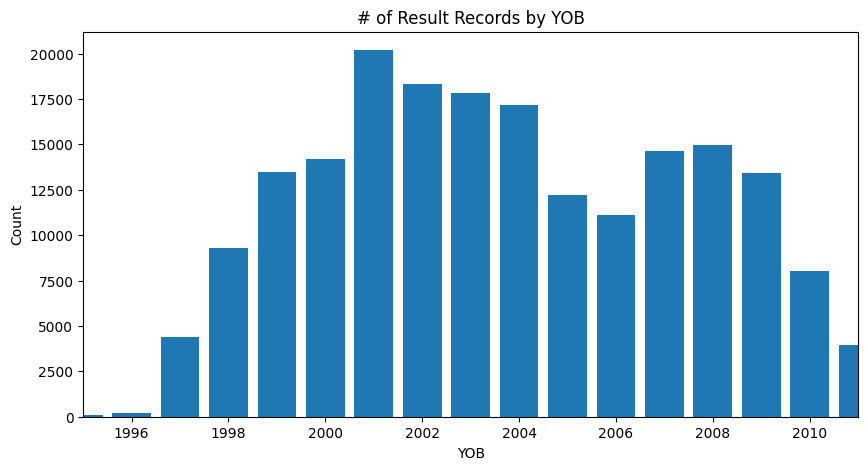

Tier
Provincial       86488
Zone             85268
International     9900
Regional          9720
National          2830
Name: count, dtype: Int64


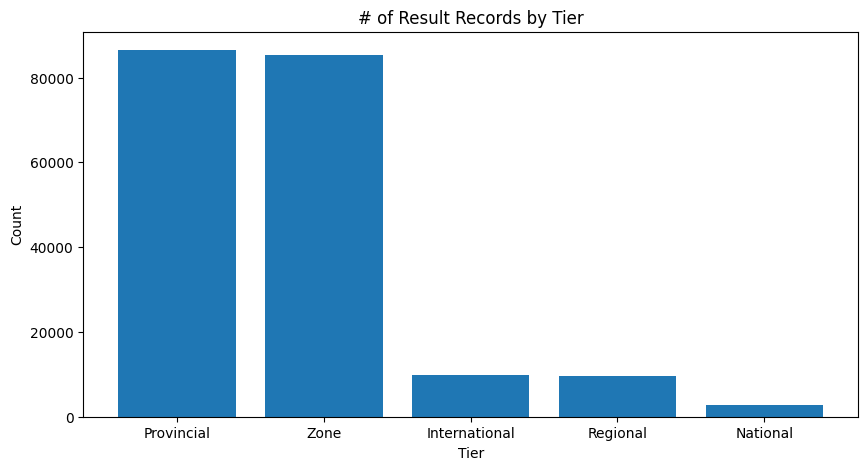

Season
2023    20053
2024    18847
2016    18840
2018    18712
2022    18325
2015    18309
2017    18283
2014    17670
2019    17111
2013    13879
2020    13234
2021      943
Name: count, dtype: int64


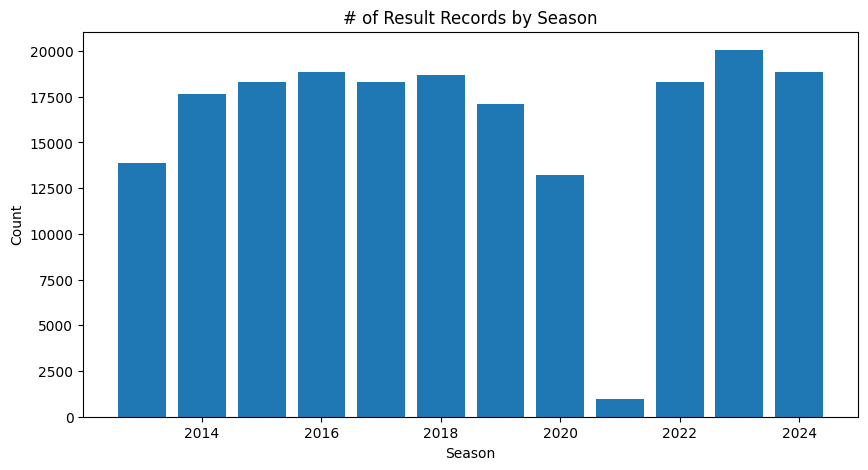

In [36]:
import matplotlib.pyplot as plt

# number of result records by gender
gender_counts = df['Gender'].value_counts()
print(gender_counts)
plt.figure(figsize=(5, 5))
plt.bar(gender_counts.index, gender_counts.values, color=['skyblue', 'pink'])
plt.title('# of Result Records by Gender')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.show()


# number of result records by YOB
yob_counts = df['YOB'].value_counts()
print(yob_counts)
plt.figure(figsize=(10, 5))
plt.bar(yob_counts.index, yob_counts.values)
plt.title('# of Result Records by YOB')
plt.xlabel('YOB')
plt.ylabel('Count')
plt.xlim(1995, 2011)
plt.show()

# number of result records by tier
tier_counts = df['Tier'].value_counts()
print(tier_counts)
plt.figure(figsize=(10, 5))
plt.bar(tier_counts.index, tier_counts.values)
plt.title('# of Result Records by Tier')
plt.xlabel('Tier')
plt.ylabel('Count')
plt.show()

# number of result records by season
season_counts = df['Season'].value_counts()
print(season_counts)
plt.figure(figsize=(10, 5))
plt.bar(season_counts.index, season_counts.values)
plt.title('# of Result Records by Season')
plt.xlabel('Season')
plt.ylabel('Count')
plt.show()

Notable observations:
* It can be difficult to classify strength by tier as a zone race in southern Ontario would likely be stronger/deeper than a zone race in Kootenay BC.
* Due to ACA only having results from 2013, there are fewer records for athletes born in the late 1990s.
* Certain provinces uploaded U14 results and others didn't. QC did not upload U14 results for many athletes.
* Lower results in 2021 due to COVID and only certain provinces having racing